In [1080]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [1081]:
df=pd.read_csv('Leo_dataset.csv')
df.head()

,Age,Salary,City (Nominal),Education_Level (Ordinal),Target
0,27.0,38146.0,Mumbai,High School,0
1,25.0,46011.0,NaN,Bachelor,0
2,29.0,57704.0,Bangalore,Bachelor,0
3,24.0,56768.0,Bangalore,Bachelor,0
4,27.0,55186.0,Delhi,Master,0


In [1082]:
df.shape

(300, 5)

### Handling Missing Values

In [1083]:
df.isna().sum()

Age                          10
Salary                        0
City (Nominal)               29
Education_Level (Ordinal)    23
Target                        0
dtype: int64

In [1084]:
df['Age_median'] = df['Age'].fillna(df['Age'].median())

In [1085]:
df.drop('Age',axis=1,inplace=True)

In [1086]:
df.head()

,Salary,City (Nominal),Education_Level (Ordinal),Target,Age_median
0,38146.0,Mumbai,High School,0,27.0
1,46011.0,NaN,Bachelor,0,25.0
2,57704.0,Bangalore,Bachelor,0,29.0
3,56768.0,Bangalore,Bachelor,0,24.0
4,55186.0,Delhi,Master,0,27.0


<Axes: ylabel='Age_median'>

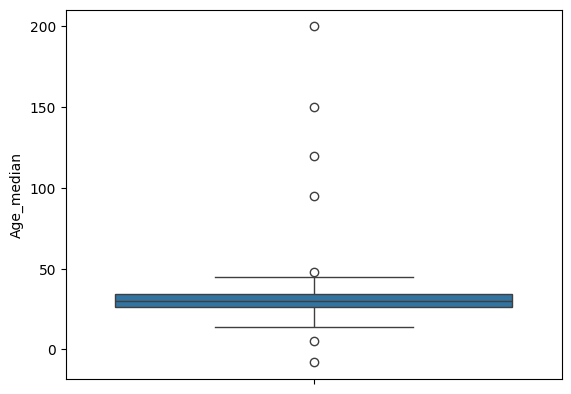

In [1087]:
sns.boxplot(df['Age_median'])

In [1088]:
min,Q1,median,Q3,max=np.quantile(df['Age_median'],[0,0.25,0.5,0.75,1.0])
print(min,Q1,median,Q3,max)

-8.0 26.0 30.0 34.0 200.0


In [1089]:
IQR = Q3-Q1
lower_fence=Q1-(1.5*IQR)
higher_fence=Q3+(1.5*IQR)
print(lower_fence)
print(higher_fence)

14.0
46.0


In [1090]:
df['Age_clipped'] = df['Age_median'].clip(lower_fence,higher_fence)

In [1091]:
df.drop('Age_median',axis=1,inplace=True)

In [1092]:
df.head()

,Salary,City (Nominal),Education_Level (Ordinal),Target,Age_clipped
0,38146.0,Mumbai,High School,0,27.0
1,46011.0,NaN,Bachelor,0,25.0
2,57704.0,Bangalore,Bachelor,0,29.0
3,56768.0,Bangalore,Bachelor,0,24.0
4,55186.0,Delhi,Master,0,27.0


<Axes: ylabel='Age_clipped'>

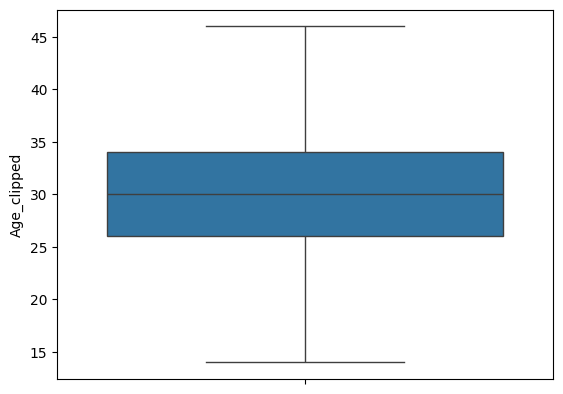

In [1093]:
sns.boxplot(df['Age_clipped'])

<Axes: ylabel='Salary'>

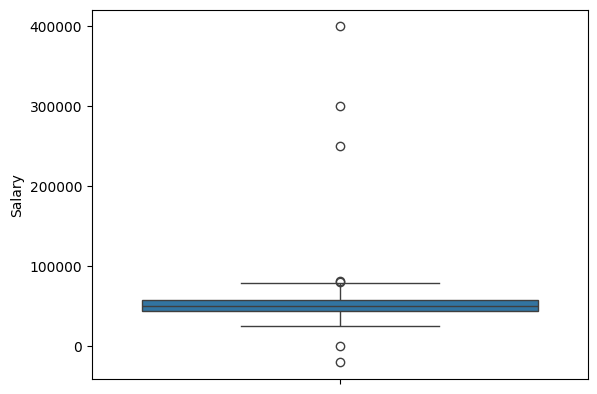

In [1094]:
sns.boxplot(df['Salary'])

In [1095]:
min,Q1,median,Q3,max=np.quantile(df['Salary'],[0,0.25,0.5,0.75,1.0])
print(min,Q1,median,Q3,max)

-20000.0 44015.25 50968.0 58532.0 400000.0


In [1096]:
IQR = Q3-Q1
lower_fence=Q1-(1.5*IQR)
higher_fence=Q3+(1.5*IQR)
print(lower_fence)
print(higher_fence)

22240.125
80307.125


In [1097]:
df['Salary_clipped'] = df['Salary'].clip(lower_fence,higher_fence)

In [1098]:
df=df.drop('Salary',axis=1)

In [1099]:
df['City'] = df['City (Nominal)'].fillna(df['City (Nominal)'].mode()[0])

In [1100]:
df.drop('City (Nominal)',axis=1,inplace=True)

In [1101]:
df.head()

,Education_Level (Ordinal),Target,Age_clipped,Salary_clipped,City
0,High School,0,27.0,38146.0,Mumbai
1,Bachelor,0,25.0,46011.0,Delhi
2,Bachelor,0,29.0,57704.0,Bangalore
3,Bachelor,0,24.0,56768.0,Bangalore
4,Master,0,27.0,55186.0,Delhi


In [1102]:
df['Education'] = df['Education_Level (Ordinal)'].fillna(df['Education_Level (Ordinal)'].mode()[0])

In [1103]:
df.drop('Education_Level (Ordinal)',axis=1,inplace=True)

In [1104]:
df.head()

,Target,Age_clipped,Salary_clipped,City,Education
0,0,27.0,38146.0,Mumbai,High School
1,0,25.0,46011.0,Delhi,Bachelor
2,0,29.0,57704.0,Bangalore,Bachelor
3,0,24.0,56768.0,Bangalore,Bachelor
4,0,27.0,55186.0,Delhi,Master


In [1105]:
df.isna().sum()

Target            0
Age_clipped       0
Salary_clipped    0
City              0
Education         0
dtype: int64

### ENCODING


In [1106]:
df['Education'].unique()

array(['High School', 'Bachelor', 'Master', 'PhD'], dtype=object)

In [1107]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD']])
encoded_1=oe.fit_transform(df[['Education']])

In [1108]:
df['Education_encoded']=pd.DataFrame(encoded_1)

In [1109]:
df.head()

,Target,Age_clipped,Salary_clipped,City,Education,Education_encoded
0,0,27.0,38146.0,Mumbai,High School,0.0
1,0,25.0,46011.0,Delhi,Bachelor,1.0
2,0,29.0,57704.0,Bangalore,Bachelor,1.0
3,0,24.0,56768.0,Bangalore,Bachelor,1.0
4,0,27.0,55186.0,Delhi,Master,2.0


In [1110]:
df.drop('Education',axis=1,inplace=True)

In [1111]:
df.head()

,Target,Age_clipped,Salary_clipped,City,Education_encoded
0,0,27.0,38146.0,Mumbai,0.0
1,0,25.0,46011.0,Delhi,1.0
2,0,29.0,57704.0,Bangalore,1.0
3,0,24.0,56768.0,Bangalore,1.0
4,0,27.0,55186.0,Delhi,2.0


In [1112]:
df.Education_encoded.unique()

array([0., 1., 2., 3.])

In [1113]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
encoded=ohe.fit_transform(df[['City']]).toarray()
encoded
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out())
encoded_df
encoded_df=pd.concat([df,encoded_df],axis=1)

In [1114]:
encoded_df.drop('City',axis=1,inplace=True)

In [1115]:
encoded_df.head()

,Target,Age_clipped,Salary_clipped,Education_encoded,City_Bangalore,City_Chennai,City_Delhi,City_Mumbai
0,0,27.0,38146.0,0.0,0.0,0.0,0.0,1.0
1,0,25.0,46011.0,1.0,0.0,0.0,1.0,0.0
2,0,29.0,57704.0,1.0,1.0,0.0,0.0,0.0
3,0,24.0,56768.0,1.0,1.0,0.0,0.0,0.0
4,0,27.0,55186.0,2.0,0.0,0.0,1.0,0.0


In [1116]:
encoded_df.Target.value_counts()

Target
0    276
1     24
Name: count, dtype: int64

### Handling Imbalance data

In [1117]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()

In [1118]:
X=encoded_df.drop('Target',axis=1)
y=encoded_df['Target']

In [1119]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

X_train_sampled,y_train_sampled=smote.fit_resample(X_train,y_train)

In [1120]:
y_train_sampled.value_counts()

Target
0    220
1    220
Name: count, dtype: int64